In [143]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

sns.set_theme(style="white", font="sans-serif")


MAIN_COLOR = "#3c6795"      
SECONDARY_COLOR = "#d95f02" 
PALETTE = "Blues_r"          


plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,   
    'axes.spines.right': False,  
})

df_clean = pd.read_csv('../data/cleaned_retail.csv')
conn = sqlite3.connect(':memory:')
df_clean.to_sql('retail', conn, index=False, if_exists='replace')


397862

In [144]:
query_1 = """
    SELECT 
        YearMonth, 
        ROUND(SUM(Revenue), 2) as Revenue
    FROM retail
    GROUP BY YearMonth
    ORDER BY YearMonth ASC
"""
monthly = pd.read_sql(query_1, conn)


In [145]:
monthly['MoM_Growth'] = monthly['Revenue'].pct_change() * 100


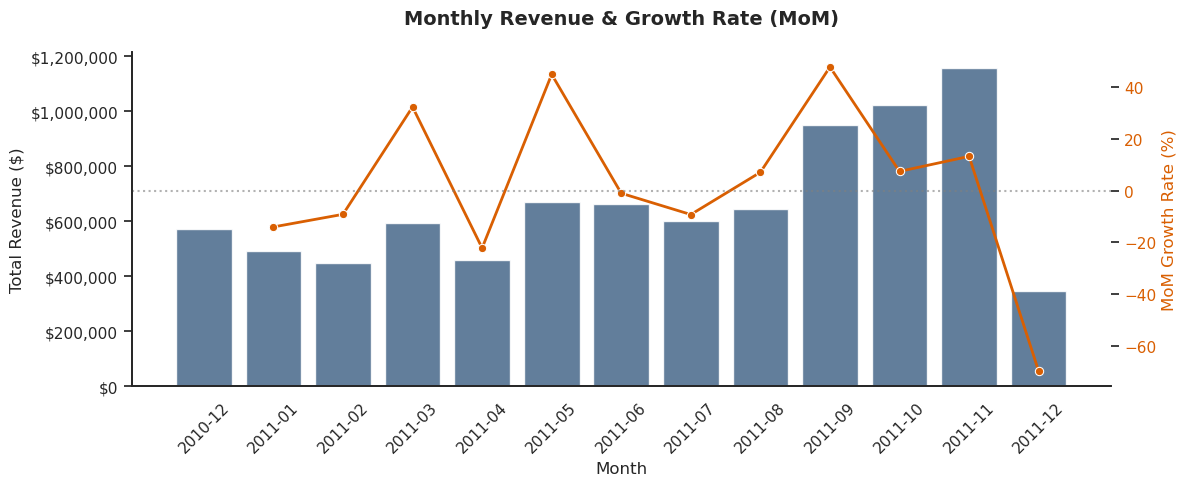

In [146]:
fig, ax1 = plt.subplots(figsize=(12, 5))


sns.barplot(data=monthly, x='YearMonth', y='Revenue', color=MAIN_COLOR, alpha=0.85, ax=ax1)
ax1.set_title('Monthly Revenue & Growth Rate (MoM)', pad=20)
ax1.set_xlabel('Month')
ax1.set_ylabel('Total Revenue ($)')
ax1.tick_params(axis='x', rotation=45)


ax1.yaxis.set_major_formatter('${x:,.0f}')

ax2 = ax1.twinx()
sns.lineplot(data=monthly, x=range(len(monthly)), y='MoM_Growth', color=SECONDARY_COLOR, 
             marker='o', markersize=6, linewidth=2, ax=ax2)
ax2.set_ylabel('MoM Growth Rate (%)', color=SECONDARY_COLOR)
ax2.tick_params(axis='y', labelcolor=SECONDARY_COLOR)
ax2.axhline(0, color='gray', linestyle=':', alpha=0.6)
ax2.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()


### Insight:
 The financial trend establishes strong Q4 seasonality, characterized by an early procurement surge from September to November. September marks the highest relative acceleration (+48% MoM Growth), while November reaches the annual revenue peak at $1.16M, driven by holiday B2B inventory accumulation. The sharp decline in December 2011 represents a data truncation artifact (data collection ends on Dec 9) rather than a contraction in underlying consumer demand.

In [147]:
query_2 = """
    SELECT 
        Country, 
        ROUND(SUM(Revenue), 2) as Revenue
    FROM retail
    GROUP BY Country
    ORDER BY Revenue DESC
"""
geo_all = pd.read_sql(query_2, conn)

In [148]:
top_countries = geo_all.head(4).copy()
others_revenue = geo_all['Revenue'].iloc[4:].sum()

In [149]:
others_df = pd.DataFrame([{'Country': 'Others', 'Revenue': others_revenue}])
geo_pie = pd.concat([top_countries, others_df], ignore_index=True)

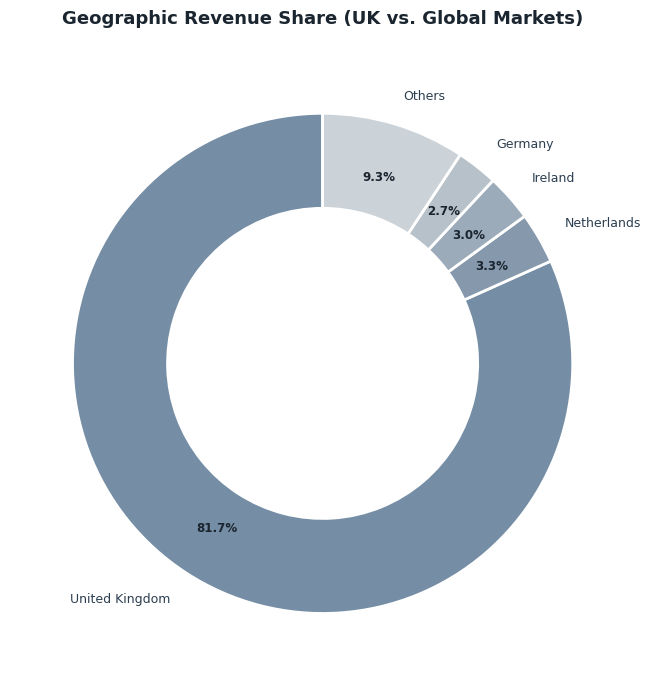

In [150]:
plt.figure(figsize=(7, 7))

custom_blues = ["#758EA5", "#8699AC", '#9BABBA', '#B7C1C9', '#CBD2D8']

wedges, texts, autotexts = plt.pie(
    geo_pie['Revenue'], 
    labels=geo_pie['Country'], 
    autopct='%1.1f%%', 
    startangle=90,           
    colors=custom_blues,
    pctdistance=0.78,        
    labeldistance=1.12,       
    textprops=dict(fontsize=9, color='#2c3e50', family='sans-serif'),
    wedgeprops=dict(width=0.38, edgecolor='white', linewidth=2)     
)

for autotext in autotexts:
    autotext.set_color('#1a252f')
    autotext.set_fontsize(8.5)
    autotext.set_weight('bold')

plt.title('Geographic Revenue Share (UK vs. Global Markets)', fontsize=13, pad=20, weight='bold', color='#1a252f')
plt.tight_layout()
plt.show()

### Insight:
 Revenue distribution reveals significant Geographic Concentration Risk, with the UK accounting for over 83% of total revenue. Conversely, international markets like the Netherlands ($285.4K across 9 clients) and EIRE ($262.2K across 3 clients) demonstrate high exposure to B2B Key Accounts with exceptionally high average revenue per user (ARPU). To mitigate single-market risk and client churn vulnerability, the business should focus on expanding its B2B partner ecosystem across Continental Europe while securing long-term service agreements (SLAs) with core international buyers.

In [151]:
query_3 = """
    SELECT 
        Description, 
        ROUND(SUM(Revenue), 2) as Revenue
    FROM retail
    GROUP BY Description
    ORDER BY Revenue DESC
"""
product_rev_df = pd.read_sql(query_3, conn)
 

In [152]:
product_rev_df['Cumulative_Pct'] = product_rev_df['Revenue'].cumsum() / product_rev_df['Revenue'].sum() * 100

def abc_class(pct):
    if pct <= 80: return 'A'
    elif pct <= 95: return 'B'
    else: return 'C'

product_rev_df['ABC'] = product_rev_df['Cumulative_Pct'].apply(abc_class)


/tmp/ipykernel_54336/1312167639.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(top_products['Description'], rotation=90, fontsize=8, color='#333333')


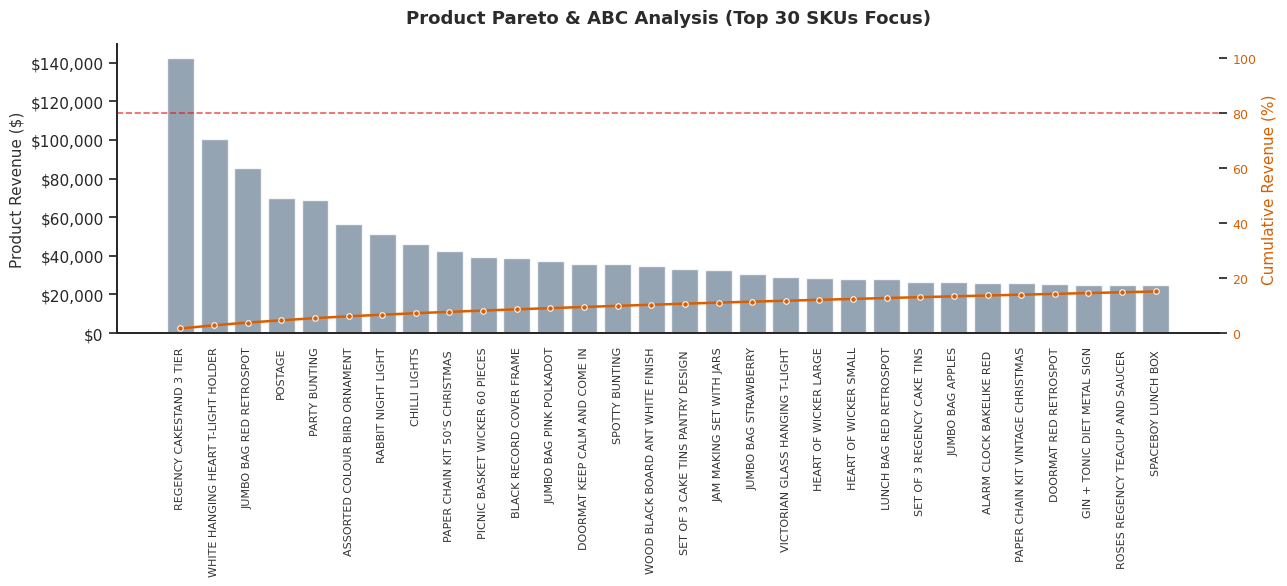

In [153]:
top_products = product_rev_df.head(30)

plt.rcParams['font.family'] = 'sans-serif'

fig, ax1 = plt.subplots(figsize=(13, 6))

sns.barplot(data=top_products, x='Description', y='Revenue', color="#758EA5", alpha=0.8, ax=ax1)

ax1.set_xticklabels(top_products['Description'], rotation=90, fontsize=8, color='#333333')
ax1.set_ylabel('Product Revenue ($)', fontsize=11, color='#333333')
ax1.set_xlabel('')
ax1.set_title('Product Pareto & ABC Analysis (Top 30 SKUs Focus)', fontsize=13, pad=15, weight='bold', color='#2b2b2b')
ax1.yaxis.set_major_formatter('${x:,.0f}')

ax1.spines['top'].set_visible(False)

ax2 = ax1.twinx()
sns.lineplot(
    data=top_products, 
    x=range(len(top_products)), 
    y='Cumulative_Pct', 
    color='#d95f02', 
    marker='o', 
    markersize=4, 
    linewidth=1.8, 
    ax=ax2
)
ax2.set_ylabel('Cumulative Revenue (%)', fontsize=11, color='#d95f02')
ax2.tick_params(axis='y', labelcolor='#d95f02', labelsize=9)
ax2.set_ylim(0, 105)

ax2.axhline(80, color='#e41a1c', linestyle='--', linewidth=1.2, alpha=0.7, label='80% Pareto Cutoff')

ax2.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()

### Insight:
 The product catalog demonstrates a steep Pareto distribution, where a highly concentrated cluster of top SKUs (Category 'A') accounts for 80% of total gross revenue. Flagship items (e.g., REGENCY CAKESTAND 3 TIER) act as primary anchors for wholesale purchasing. To prevent catastrophic revenue loss from stockout events, the supply chain team must implement safety stock buffers and prioritized inventory fulfillment protocols specifically for Class 'A' merchandise.

In [154]:
query_4 = """
    SELECT 
        YearMonth,
        ROUND(AVG(Invoice_Total), 2) as AOV
    FROM (
        SELECT YearMonth, Invoice, SUM(Revenue) as Invoice_Total
        FROM retail
        GROUP BY YearMonth, Invoice
    )
    GROUP BY YearMonth
    ORDER BY YearMonth ASC
"""
aov = pd.read_sql(query_4, conn)

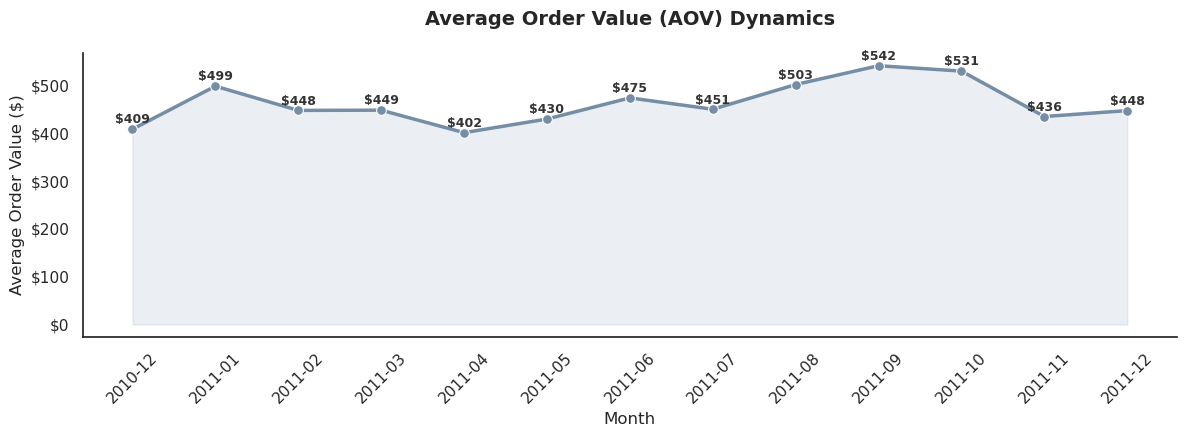

In [155]:
plt.figure(figsize=(12, 4.5))

sns.lineplot(data=aov, x='YearMonth', y='AOV', color="#758EA5", marker='o', linewidth=2.5, markersize=7)
plt.fill_between(range(len(aov)), aov['AOV'], color=MAIN_COLOR, alpha=0.1) 

plt.title('Average Order Value (AOV) Dynamics', pad=20)
plt.xlabel('Month')
plt.ylabel('Average Order Value ($)')
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter('${x:,.0f}')

for x, y in zip(range(len(aov)), aov['AOV']):
    plt.text(x, y + 12, f"${y:.0f}", ha='center', fontsize=9, fontweight='bold', color='#333333')

plt.tight_layout()
plt.show()

### Insight:
 AOV declines during the peak Q4 season despite total revenue growth, as buyers shift to smaller, high-frequency replenishment orders. This disparity increases per-order fulfillment and logistics costs. To protect profit margins, the business should implement Minimum Order Quantities (MOQs) or tiered shipping fees during peak demand.

In [156]:
conn.close()